# Notebook 06: Model Explainability

## Objective

The objective of this notebook is to explain the predictions made by the best machine learning model.

This notebook focuses on:

- Loading the best trained model
- Understanding global feature importance
- Explaining which features influence machine failure prediction
- Preparing explainability outputs for the dashboard and report

In [1]:
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

In [2]:
best_model_name = joblib.load("../models/trained_models/best_model_name.pkl")

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [3]:
models = {
    "Logistic Regression": "../models/trained_models/logistic_regression.pkl",
    "Decision Tree": "../models/trained_models/decision_tree.pkl",
    "Random Forest": "../models/trained_models/random_forest.pkl",
    "XGBoost": "../models/trained_models/xgboost.pkl"
}

best_model = joblib.load(models[best_model_name])

print("Best model loaded successfully!")

Best model loaded successfully!


In [4]:
X_test = joblib.load("../models/preprocessing/X_test.pkl")
y_test = joblib.load("../models/preprocessing/y_test.pkl")

feature_names = joblib.load("../models/preprocessing/feature_names.pkl")

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

X_test_df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Temperature Difference,Mechanical Power,Wear Rate,Thermal Stress
0,-0.333221,0.247681,-0.139294,-1.073963,2.265378,0.712410,-0.067233,-0.104244,-0.101765,-0.101765,-0.043342,-0.700758,2.376605,1.010492,1.689336
1,-0.333221,1.850310,1.618248,-0.145641,0.009646,0.429427,-0.067233,-0.104244,-0.101765,-0.101765,-0.043342,-1.300884,0.066084,0.434031,-0.473702
2,-0.333221,1.249324,0.942270,0.108543,-0.239882,1.592802,-0.067233,-0.104244,-0.101765,-0.101765,-0.043342,-1.100842,-0.134390,1.487720,-0.605106
3,-2.007699,-2.206344,-2.505215,-0.167744,-0.419543,-0.749670,-0.067233,-0.104244,-0.101765,-0.101765,-0.043342,0.699533,-0.583229,-0.728513,-0.157982
4,-2.007699,0.247681,-0.004098,-1.002129,2.035812,-0.089376,-0.067233,-0.104244,-0.101765,-0.101765,-0.043342,-0.500717,2.151190,0.102268,1.603365


In [5]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    importance_df
else:
    print("Selected model does not provide feature_importances_.")

Selected model does not provide feature_importances_.


In [6]:
if hasattr(best_model, "feature_importances_"):
    plt.figure(figsize=(10,6))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )

    plt.title(f"Feature Importance - {best_model_name}")
    plt.show()

In [8]:
# SHAP Explainer

explainer = shap.Explainer(
    best_model,
    X_test_df
)

shap_values = explainer(X_test_df)

print("SHAP values calculated successfully!")

Background dataset has 2000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2000 when initializing the masker.


SHAP values calculated successfully!


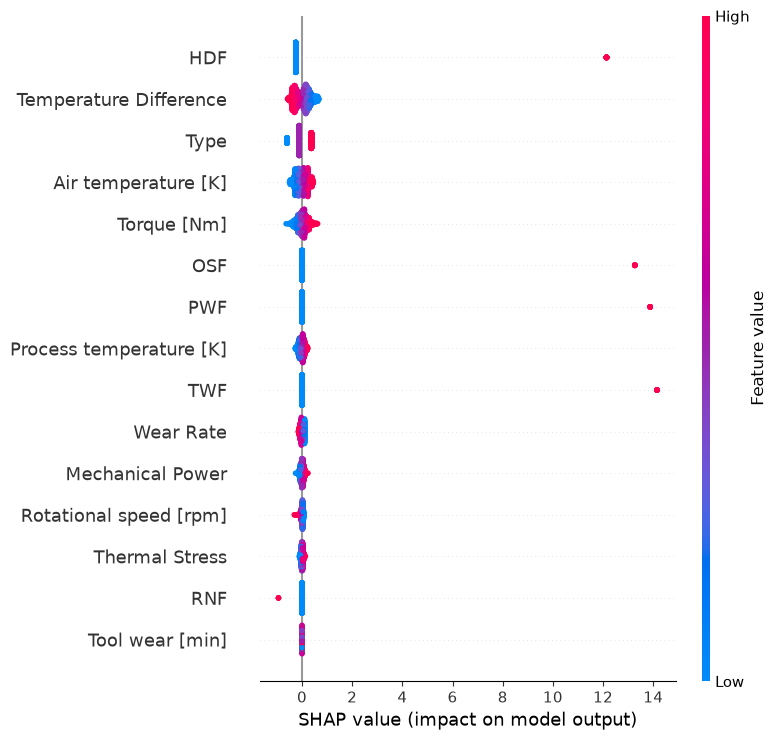

In [9]:
shap.summary_plot(
    shap_values,
    X_test_df
)

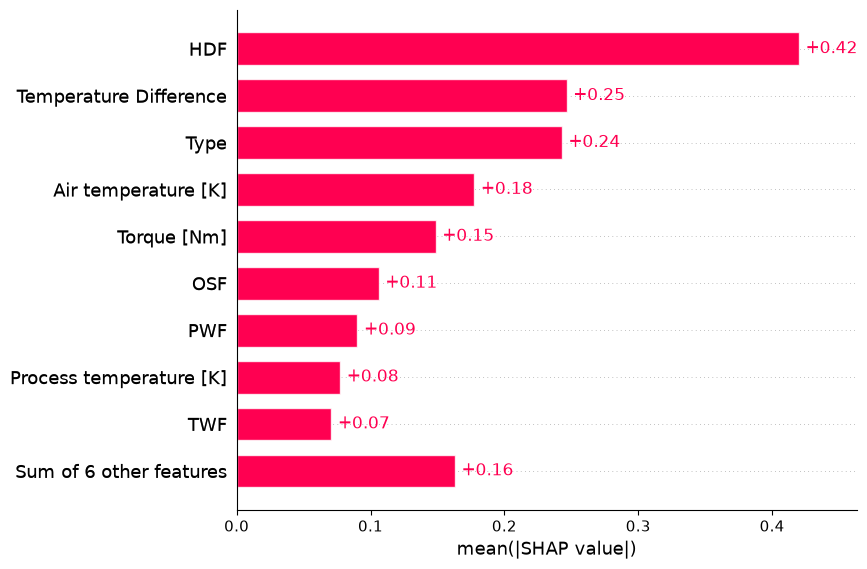

In [10]:
shap.plots.bar(shap_values)

c:\Users\opurv\Documents\smart-manufacturing-predictive-maintenance\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\opurv\Documents\smart-manufacturing-predictive-maintenance\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Prediction: 0
Failure Probability: 0.17%


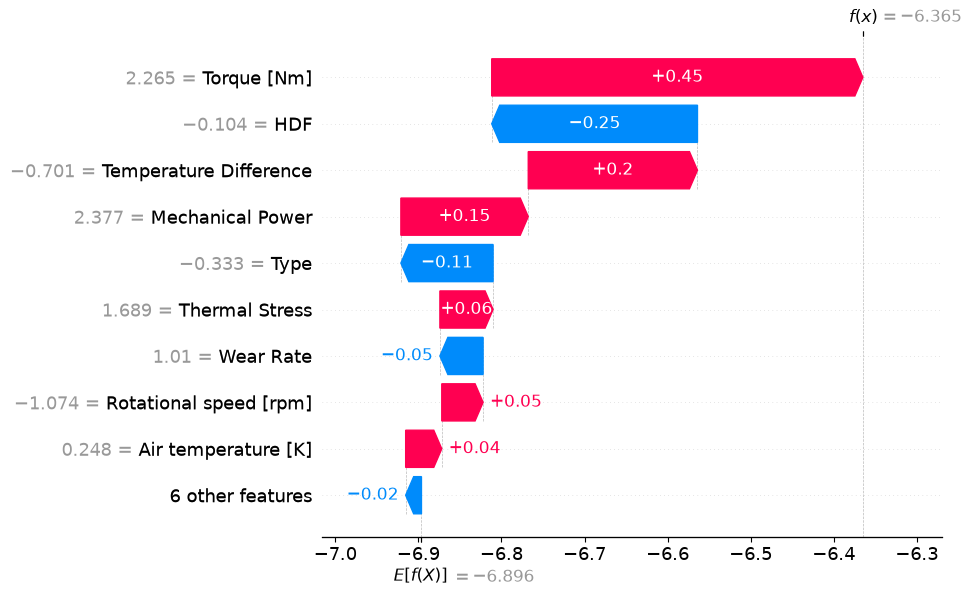

In [11]:
sample_index = 0

prediction = best_model.predict(X_test_df.iloc[[sample_index]])[0]
probability = best_model.predict_proba(X_test_df.iloc[[sample_index]])[0][1]

print("Prediction:", prediction)
print(f"Failure Probability: {probability:.2%}")

shap.plots.waterfall(shap_values[sample_index])

In [12]:
mean_shap_values = np.abs(shap_values.values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean SHAP Value": mean_shap_values
})

shap_importance_df = shap_importance_df.sort_values(
    by="Mean SHAP Value",
    ascending=False
)

shap_importance_df.to_csv(
    "../reports/shap_feature_importance.csv",
    index=False
)

shap_importance_df

,Feature,Mean SHAP Value
7,HDF,0.420049
11,Temperature Difference,0.246434
0,Type,0.242879
1,Air temperature [K],0.177514
4,Torque [Nm],0.148667
9,OSF,0.106135
8,PWF,0.090217
2,Process temperature [K],0.077359
6,TWF,0.070741
13,Wear Rate,0.053076


# Notebook Summary

✔ Loaded the best trained model

✔ Analyzed model feature importance

✔ Applied SHAP explainability

✔ Identified the most influential features affecting machine failure prediction

✔ Explained an individual prediction

✔ Saved explainability outputs for dashboard and reporting